In [29]:
# Load test data
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

PRJ_DIR = os.path.dirname(os.getcwd())
MODEL_DIR = os.path.join(PRJ_DIR, 'results','models')

# Load test data
test_data = pd.read_csv(os.path.join(PRJ_DIR, 'data', 'test', 'data.csv'))
print(f"Test data shape: {test_data.shape}")
print(f"Columns: {list(test_data.columns)}")

# Prepare features and labels
X_test = test_data.drop(['result'], axis=1).values
y_test = test_data['result'].values

# Encode labels: W=0, D=1, L=2
result_map = {'W': 0, 'D': 1, 'L': 2}
y_test_encoded = np.array([result_map[val] for val in y_test])

# Scale features
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

print(f"\nX_test shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test_encoded.shape}")
print(f"Class distribution: W={np.sum(y_test_encoded==0)}, D={np.sum(y_test_encoded==1)}, L={np.sum(y_test_encoded==2)}")

Test data shape: (55756, 21)
Columns: ['ht_goal', 'at_goal', 'ht_elo', 'at_elo', 'shot', 'big_chance', 'shot_penalty_box', 'key_pass', 'pass', 'short_pass', 'shot_open_play', 'final_3rd_pass', 'minute', 'shot_6_yard_box', 'dispossessed', 'clearance', 'long_pass', 'cross', 'shot_fast_break', 'tackle', 'result']

X_test shape: (55756, 20)
y_test shape: (55756,)
Class distribution: W=24654, D=12527, L=18575


In [30]:
# List available models
print("Available models in /model folder:")
model_files = [f for f in os.listdir(MODEL_DIR) if f.endswith('.pkl')]
for f in sorted(model_files):
    print(f"  - {f}")

Available models in /model folder:
  - decision_tree.pkl
  - decision_tree_calibrated.pkl
  - knn.pkl
  - knn_calibrated.pkl
  - preprocessor.pkl
  - random_forest.pkl
  - random_forest_calibrated.pkl
  - rf_feature_importance.pkl
  - scaler.pkl
  - shap_explainer.pkl
  - xgboost.pkl
  - xgboost_calibrated.pkl


In [31]:
# Define evaluation metrics
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix
from torch import tensor
from torchmetrics.classification import MulticlassCalibrationError
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize calibration error metrics
ece = MulticlassCalibrationError(num_classes=3, n_bins=20, norm='l1')
mce = MulticlassCalibrationError(num_classes=3, n_bins=20, norm='max')

def rps_score(outcomes, predictions):
    """Calculate Ranked Probability Score (RPS)"""
    loss = 0
    for i, p in enumerate(predictions):
        outcome = [1 if x == outcomes[i] else 0 for x in range(3)]
        tmp = probs = outs = 0
        for j, val in enumerate(predictions[i]):
            probs += val
            outs += outcome[j]
            tmp += (probs - outs) ** 2
        loss += tmp / 2
    loss /= len(predictions)
    return 1 - loss

def evaluate_model(model, model_name, X, y_true):
    """Evaluate a single model and return metrics"""
    # Get predictions
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    logloss = log_loss(y_true, y_proba, labels=[0, 1, 2])
    rps = rps_score(y_true, y_proba)
    
    # Calculate ECE and MCE
    ece_score = ece(tensor(y_proba).float(), tensor(y_true)).item()
    mce_score = mce(tensor(y_proba).float(), tensor(y_true)).item()
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'log_loss': logloss,
        'rps': rps,
        'ece': ece_score,
        'mce': mce_score,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

print("Evaluation functions defined (with ECE, MCE).")

Evaluation functions defined (with ECE, MCE).


In [32]:
# Evaluate all models
results = []

for model_file in sorted(model_files):
    model_path = os.path.join(MODEL_DIR, model_file)
    model_name = model_file.replace('.pkl', '')
    
    print(f"\n{'='*60}")
    print(f"Evaluating: {model_name}")
    print('='*60)
    
    try:
        # Load model
        model = joblib.load(model_path)
        
        # Check feature count
        if hasattr(model, 'n_features_in_'):
            expected_features = model.n_features_in_
            actual_features = X_test_scaled.shape[1]
            if expected_features != actual_features:
                print(f"  ⚠️  Feature mismatch: model expects {expected_features}, test data has {actual_features}")
                print(f"  Skipping this model - needs to be retrained with current features")
                continue
        
        # Evaluate
        result = evaluate_model(model, model_name, X_test_scaled, y_test_encoded)
        results.append(result)
        
        print(f"  Accuracy:  {result['accuracy']:.4f}")
        print(f"  Log Loss:  {result['log_loss']:.4f}")
        print(f"  RPS Score: {result['rps']:.4f}")
        print(f"  ECE:       {result['ece']:.4f}")
        print(f"  MCE:       {result['mce']:.4f}")
        
    except KeyError as e:
        print(f"  ❌ Pickle compatibility error: KeyError {e}")
        print(f"     The model was saved with an older Python version.")
        print(f"     Please retrain this model with Python {sys.version.split()[0]}")
        
    except Exception as e:
        print(f"  ❌ Error: {type(e).__name__}: {e}")

print(f"\n{'='*60}")
print(f"Evaluated {len(results)} models successfully")


Evaluating: decision_tree
  Accuracy:  0.6448
  Log Loss:  1.5652
  RPS Score: 0.8332
  ECE:       0.1307
  MCE:       0.7261

Evaluating: decision_tree_calibrated
  Accuracy:  0.6448
  Log Loss:  1.4665
  RPS Score: 0.8340
  ECE:       0.1255
  MCE:       0.8451

Evaluating: knn
  Accuracy:  0.5244
  Log Loss:  13.6794
  RPS Score: 0.7268
  ECE:       0.3825
  MCE:       0.4259

Evaluating: knn_calibrated
  Accuracy:  0.5244
  Log Loss:  2.4135
  RPS Score: 0.7262
  ECE:       0.3890
  MCE:       0.4211

Evaluating: preprocessor
  ❌ Error: ModuleNotFoundError: No module named 'preprocessor'

Evaluating: random_forest
  Accuracy:  0.6302
  Log Loss:  0.9450
  RPS Score: 0.8378
  ECE:       0.0927
  MCE:       0.1331

Evaluating: random_forest_calibrated
  Accuracy:  0.6283
  Log Loss:  4.2435
  RPS Score: 0.7974
  ECE:       0.2678
  MCE:       0.3995

Evaluating: rf_feature_importance
  ⚠️  Feature mismatch: model expects 28, test data has 20
  Skipping this model - needs to be retra

In [33]:
# Create results summary table
results_df = pd.DataFrame([{
    'Model': r['model'],
    'Accuracy': r['accuracy'],
    'Log Loss': r['log_loss'],
    'RPS': r['rps'],
    'ECE': r['ece'],
    'MCE': r['mce']
} for r in results])

# Sort by RPS (higher is better)
results_df = results_df.sort_values('RPS', ascending=False).reset_index(drop=True)

# Display results
print("Model Evaluation Results (sorted by RPS):\n")
display(results_df.style.format({
    'Accuracy': '{:.4f}',
    'Log Loss': '{:.4f}',
    'RPS': '{:.4f}',
    'ECE': '{:.4f}',
    'MCE': '{:.4f}'
}).background_gradient(subset=['RPS'], cmap='Greens')
 .background_gradient(subset=['Accuracy'], cmap='Blues')
 .background_gradient(subset=['Log Loss'], cmap='Reds_r')
 .background_gradient(subset=['ECE'], cmap='Reds_r')
 .background_gradient(subset=['MCE'], cmap='Reds_r'))

Model Evaluation Results (sorted by RPS):



,Model,Accuracy,Log Loss,RPS,ECE,MCE
0,random_forest,0.6302,0.9450,0.8378,0.0927,0.1331
1,decision_tree_calibrated,0.6448,1.4665,0.8340,0.1255,0.8451
2,decision_tree,0.6448,1.5652,0.8332,0.1307,0.7261
3,random_forest_calibrated,0.6283,4.2435,0.7974,0.2678,0.3995
4,xgboost,0.5589,2.2506,0.7453,0.3402,0.4588
5,xgboost_calibrated,0.5554,9.7808,0.7302,0.3810,0.5298
6,knn,0.5244,13.6794,0.7268,0.3825,0.4259
7,knn_calibrated,0.5244,2.4135,0.7262,0.3890,0.4211


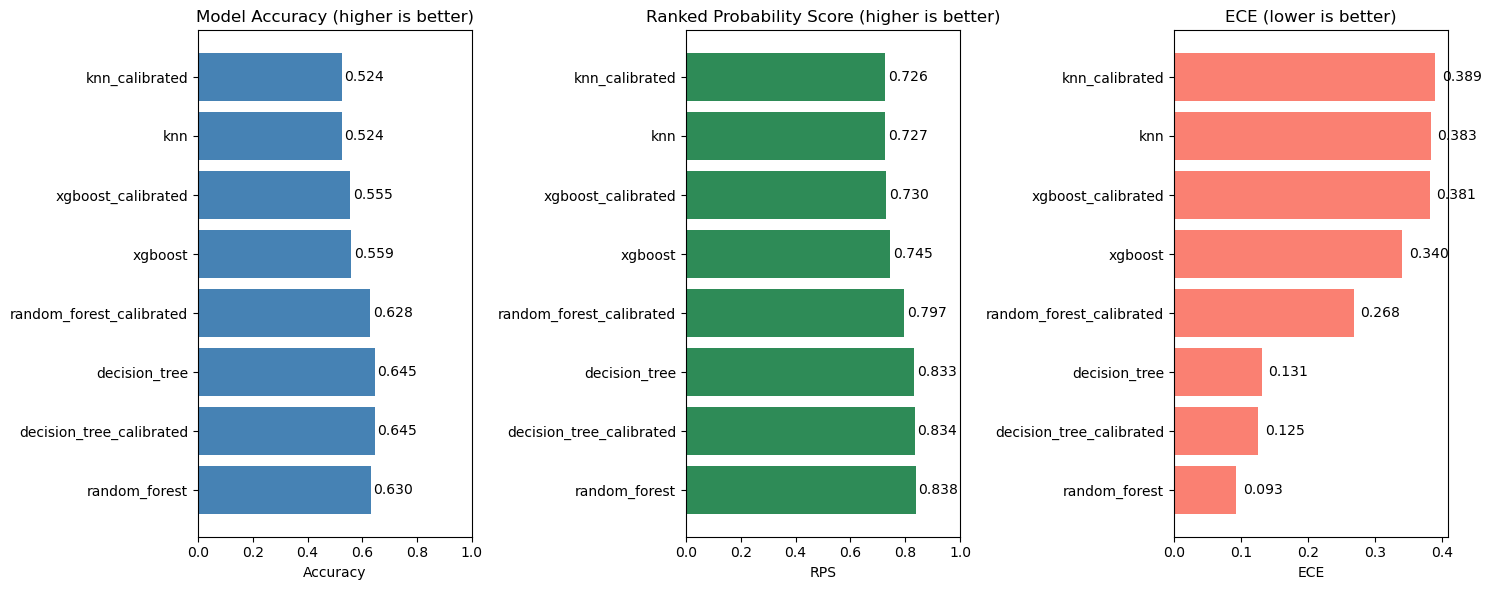

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Accuracy plot
ax1 = axes[0]
bars1 = ax1.barh(results_df['Model'], results_df['Accuracy'], color='steelblue')
ax1.set_xlabel('Accuracy')
ax1.set_title('Model Accuracy (higher is better)')
ax1.set_xlim(0, 1)
for bar, val in zip(bars1, results_df['Accuracy']):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# Log Loss plot
# ax2 = axes[0][1]
# bars2 = ax2.barh(results_df['Model'], results_df['Log Loss'], color='salmon')
# ax2.set_xlabel('Log Loss')
# ax2.set_title('Log Loss (lower is better)')
# for bar, val in zip(bars2, results_df['Log Loss']):
#     ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# RPS plot
ax3 = axes[1]
bars3 = ax3.barh(results_df['Model'], results_df['RPS'], color='seagreen')
ax3.set_xlabel('RPS')
ax3.set_title('Ranked Probability Score (higher is better)')
ax3.set_xlim(0, 1)
for bar, val in zip(bars3, results_df['RPS']):
    ax3.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# ECE plot
ax4 = axes[2]
bars4 = ax4.barh(results_df['Model'], results_df['ECE'], color='salmon')
ax4.set_xlabel('ECE')
ax4.set_title('ECE (lower is better)')
for bar, val in zip(bars4, results_df['ECE']):
    ax4.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

plt.tight_layout()
plt.show()

Best Model: random_forest

Classification Report:
              precision    recall  f1-score   support

     Win (W)       0.67      0.78      0.72     24654
    Draw (D)       0.41      0.27      0.33     12527
    Loss (L)       0.66      0.67      0.67     18575

    accuracy                           0.63     55756
   macro avg       0.58      0.58      0.57     55756
weighted avg       0.61      0.63      0.62     55756



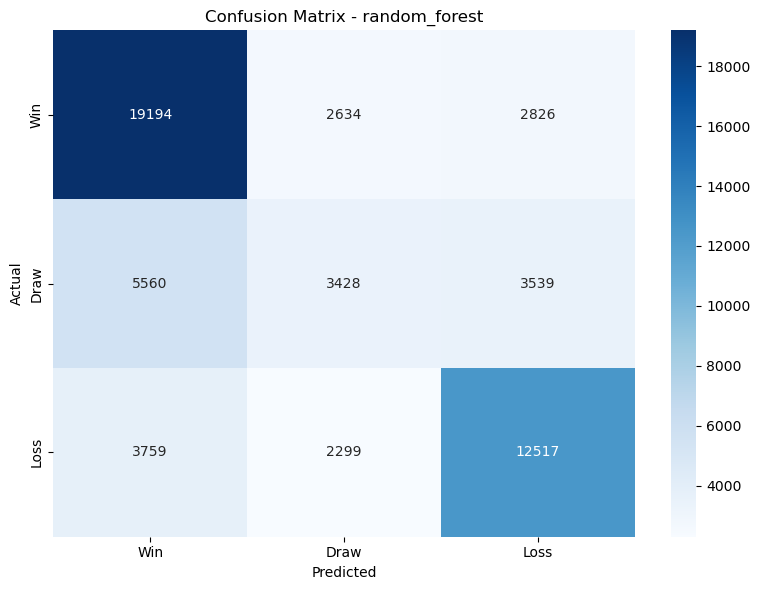

In [35]:
# Confusion matrix for best model (by RPS)
best_model_name = results_df.iloc[0]['Model']
best_result = next(r for r in results if r['model'] == best_model_name)

print(f"Best Model: {best_model_name}")
print(f"\nClassification Report:")
print(classification_report(y_test_encoded, best_result['y_pred'], 
                            target_names=['Win (W)', 'Draw (D)', 'Loss (L)']))

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test_encoded, best_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Win', 'Draw', 'Loss'],
            yticklabels=['Win', 'Draw', 'Loss'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

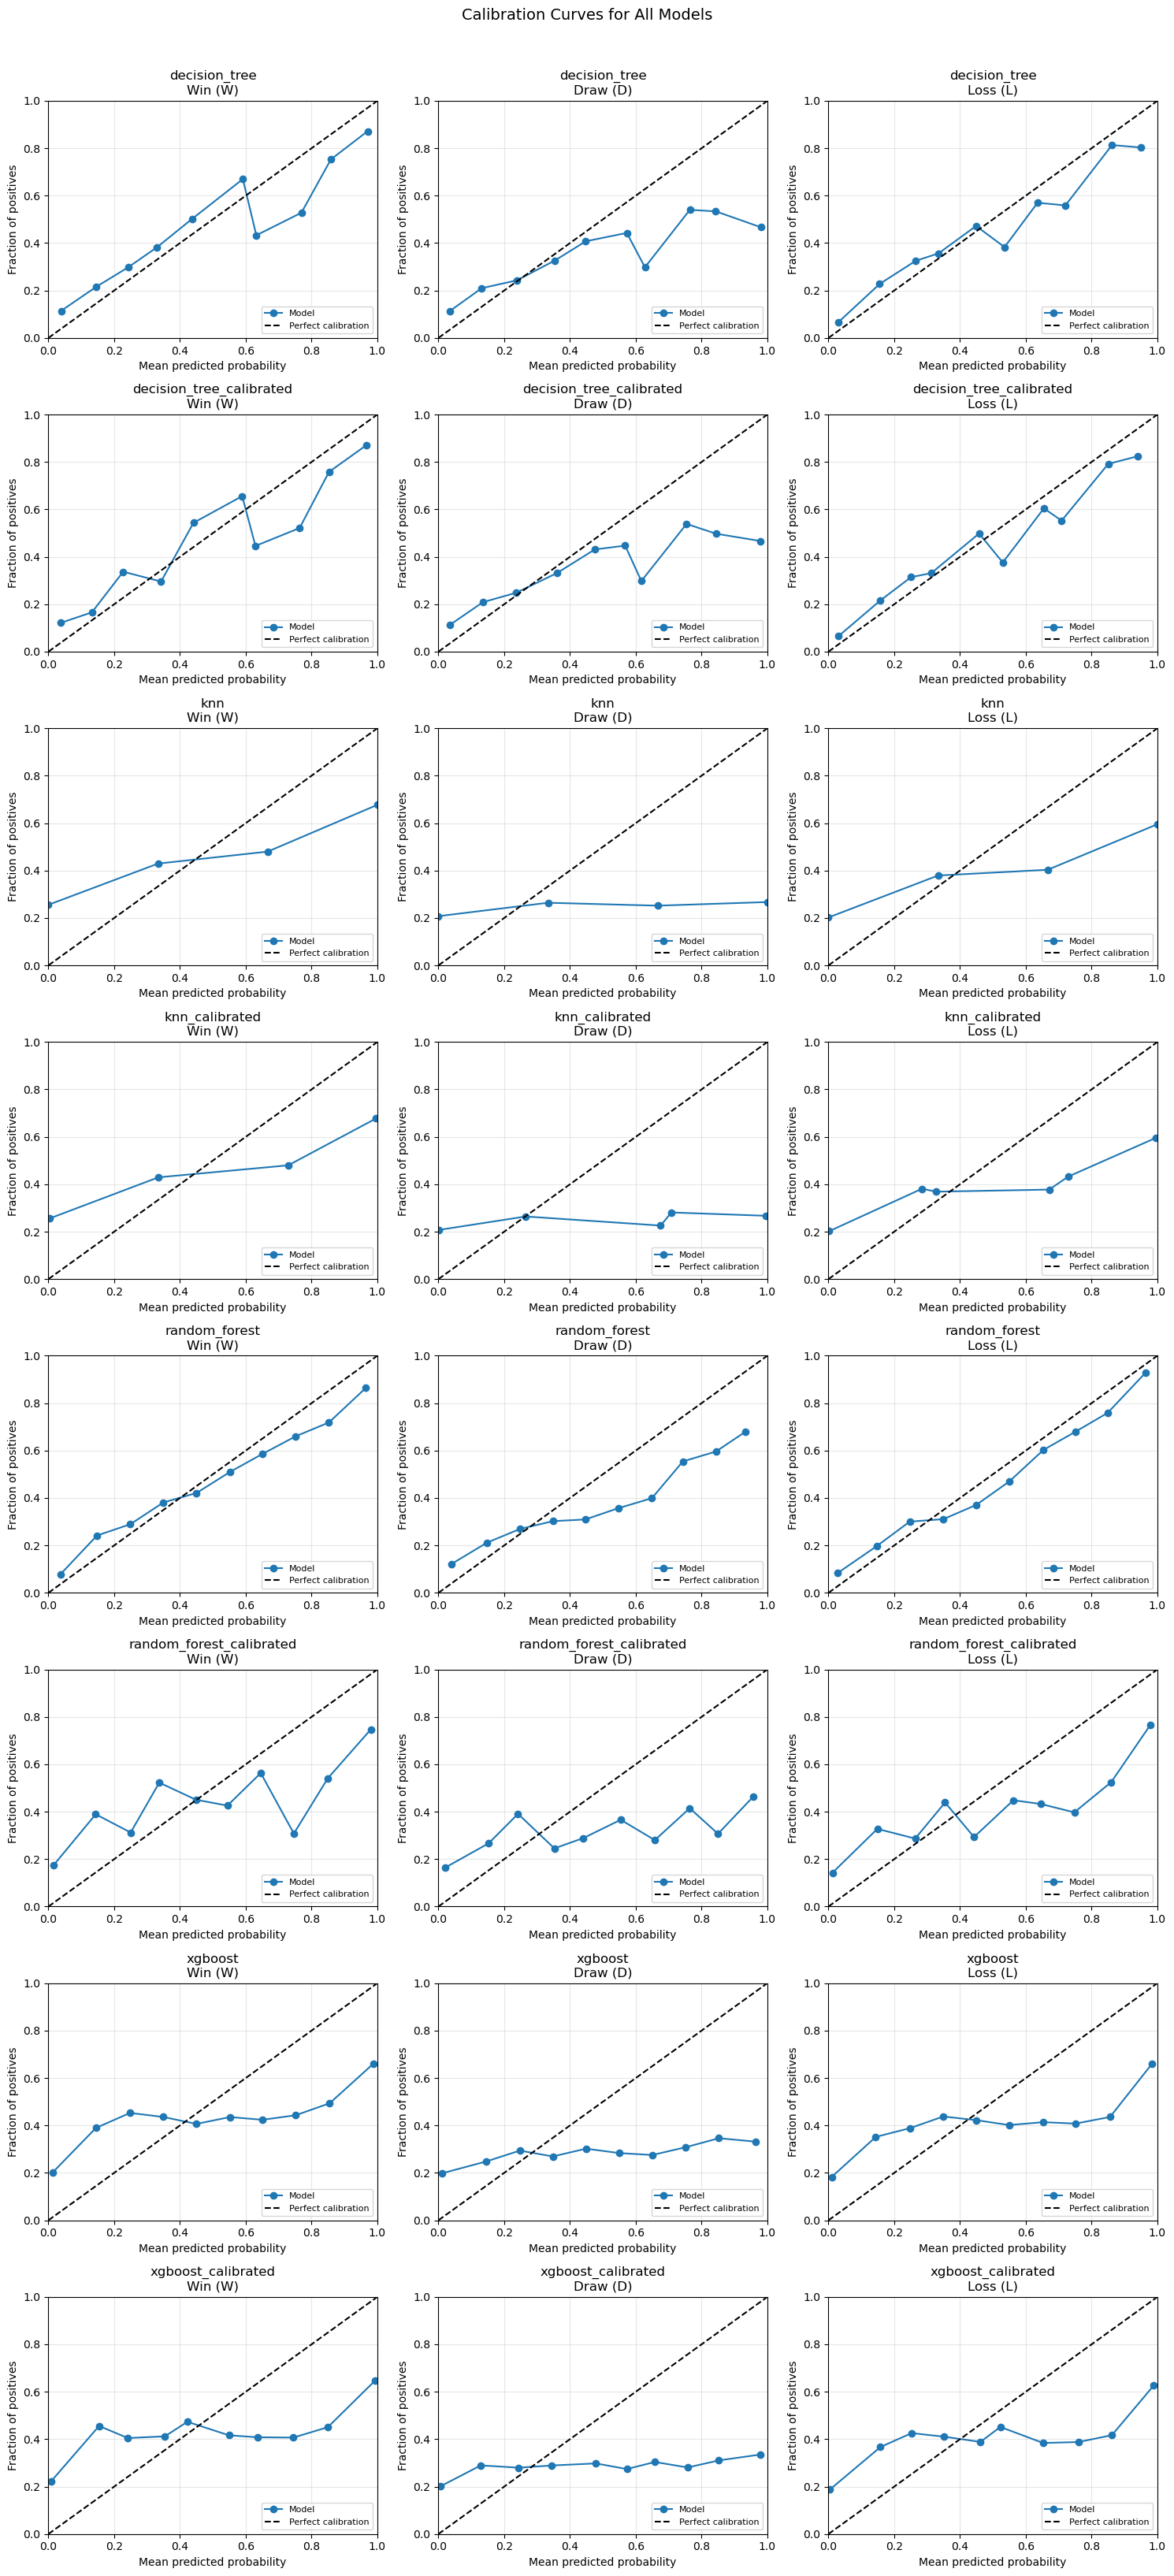

In [36]:
# Calibration curves for all models
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(len(results), 3, figsize=(15, 4 * len(results)))
if len(results) == 1:
    axes = axes.reshape(1, -1)

class_names = ['Win (W)', 'Draw (D)', 'Loss (L)']

for idx, result in enumerate(results):
    for class_idx in range(3):
        ax = axes[idx, class_idx]
        
        # Calculate calibration curve
        prob_true, prob_pred = calibration_curve(
            y_test_encoded == class_idx,
            result['y_proba'][:, class_idx],
            n_bins=10,
            strategy='uniform'
        )
        
        # Plot calibration curve
        ax.plot(prob_pred, prob_true, marker='o', label='Model')
        ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
        ax.set_xlabel('Mean predicted probability')
        ax.set_ylabel('Fraction of positives')
        ax.set_title(f"{result['model']}\n{class_names[class_idx]}")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc='lower right', fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Calibration Curves for All Models', y=1.02, fontsize=14)
plt.show()

In [37]:
# Summary
print("="*60)
print("EVALUATION SUMMARY")
print("="*60)
print(f"\nTotal models evaluated: {len(results)}")
print(f"\nBest model by RPS: {results_df.iloc[0]['Model']}")
print(f"  - RPS: {results_df.iloc[0]['RPS']:.4f}")
print(f"  - Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"  - Log Loss: {results_df.iloc[0]['Log Loss']:.4f}")
print(f"  - ECE: {results_df.iloc[0]['ECE']:.4f}")
print(f"  - MCE: {results_df.iloc[0]['MCE']:.4f}")

print(f"\nBest model by Accuracy: {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']}")
print(f"  - Accuracy: {results_df['Accuracy'].max():.4f}")

print(f"\nBest model by Log Loss: {results_df.loc[results_df['Log Loss'].idxmin(), 'Model']}")
print(f"  - Log Loss: {results_df['Log Loss'].min():.4f}")

print(f"\nBest model by ECE (lowest): {results_df.loc[results_df['ECE'].idxmin(), 'Model']}")
print(f"  - ECE: {results_df['ECE'].min():.4f}")

print(f"\nBest model by MCE (lowest): {results_df.loc[results_df['MCE'].idxmin(), 'Model']}")
print(f"  - MCE: {results_df['MCE'].min():.4f}")

EVALUATION SUMMARY

Total models evaluated: 8

Best model by RPS: random_forest
  - RPS: 0.8378
  - Accuracy: 0.6302
  - Log Loss: 0.9450
  - ECE: 0.0927
  - MCE: 0.1331

Best model by Accuracy: decision_tree_calibrated
  - Accuracy: 0.6448

Best model by Log Loss: random_forest
  - Log Loss: 0.9450

Best model by ECE (lowest): random_forest
  - ECE: 0.0927

Best model by MCE (lowest): random_forest
  - MCE: 0.1331
